In [1]:
import pandas as pd
import yfinance as yf
import psycopg2
from psycopg2.extras import execute_values
import json
import time
import numpy as np
from IPython.display import display, Markdown

# ==========================================
# 1. จัดการข้อมูลจาก GitHub -> Table: set_master_v2
# ==========================================
print("🔄 1. กำลังดึงข้อมูลรายชื่อหุ้นจาก GitHub...")
github_url = "https://raw.githubusercontent.com/langsari/big-data-fin-2026/refs/heads/main/shifa_set_datafin/data/raw/listedCompanies_th_TH.csv"

try:
    df_set = pd.read_csv(github_url, encoding='utf-8', skiprows=1)
except UnicodeDecodeError:
    df_set = pd.read_csv(github_url, encoding='tis-620', skiprows=1)

df_set.rename(columns={
    'หลักทรัพย์': 'symbol', 'บริษัท': 'company_name_th', 'ตลาด': 'market',
    'กลุ่มอุตสาหกรรม': 'industry_group', 'หมวดธุรกิจ': 'sector_th',
    'ที่อยู่': 'address', 'รหัสไปรษณีย์': 'zipcode', 'โทรศัพท์': 'phone',
    'โทรสาร': 'fax', 'เว๊บไซต์': 'website'
}, inplace=True)

df_set = df_set.replace({np.nan: None})
df_set = df_set[~df_set['symbol'].str.contains('-', na=False)]

try:
    conn = psycopg2.connect(host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459")
    cur = conn.cursor()
    
    # สร้างตาราง 1: set_master_v2
    cur.execute("DROP TABLE IF EXISTS set_master_v2 CASCADE;")
    cur.execute("""
        CREATE TABLE set_master_v2 (
            symbol VARCHAR(20) PRIMARY KEY, company_name_th VARCHAR(255), market VARCHAR(50),
            industry_group VARCHAR(100), sector_th VARCHAR(100), address TEXT, zipcode VARCHAR(20),
            phone VARCHAR(100), fax VARCHAR(100), website VARCHAR(255), updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        );
    """)
    
    insert_master = """
        INSERT INTO set_master_v2 (symbol, company_name_th, market, industry_group, sector_th, address, zipcode, phone, fax, website)
        VALUES %s ON CONFLICT (symbol) DO NOTHING;
    """
    records_master = [tuple(x) for x in df_set[['symbol', 'company_name_th', 'market', 'industry_group', 'sector_th', 'address', 'zipcode', 'phone', 'fax', 'website']].to_numpy()]
    execute_values(cur, insert_master, records_master)
    conn.commit()
    print(f"✅ สร้างและบันทึกข้อมูลตาราง 'set_master_v2' สำเร็จ ({len(df_set)} บริษัท)")

    # ==========================================
    # 2. ดึงข้อมูล Fundamental จาก yfinance -> Table: yfinance_info_v2
    # ==========================================
    print("\n🔄 2. กำลังดึงข้อมูลปัจจัยพื้นฐานจาก yfinance (รอสักครู่)...")
    cur.execute("DROP TABLE IF EXISTS yfinance_info_v2 CASCADE;")
    cur.execute("""
        CREATE TABLE yfinance_info_v2 (
            symbol VARCHAR(20) PRIMARY KEY, long_name VARCHAR(255), sector VARCHAR(100), industry VARCHAR(100),
            market_cap BIGINT, beta FLOAT, dividend_yield FLOAT, trailing_pe FLOAT, current_price FLOAT, raw_info_json JSONB
        );
    """)
    
    insert_yf = """
        INSERT INTO yfinance_info_v2 (symbol, long_name, sector, industry, market_cap, beta, dividend_yield, trailing_pe, current_price, raw_info_json)
        VALUES %s ON CONFLICT (symbol) DO NOTHING;
    """
    
    symbols = df_set['symbol'].str.strip().tolist()
    records_yf = []
    
    for sym in symbols:
        try:
            info = yf.Ticker(f"{sym}.BK").info
            if 'regularMarketPrice' not in info and 'currentPrice' not in info:
                continue
            records_yf.append((
                sym, info.get('longName'), info.get('sector'), info.get('industry'), info.get('marketCap'),
                info.get('beta'), info.get('dividendYield'), info.get('trailingPE'), 
                info.get('currentPrice', info.get('regularMarketPrice')), json.dumps(info)
            ))
        except: continue
        
    execute_values(cur, insert_yf, records_yf)
    conn.commit()
    print(f"✅ สร้างและบันทึกข้อมูลตาราง 'yfinance_info_v2' สำเร็จ ({len(records_yf)} บริษัท)")

    # ==========================================
    # 3. ดึงราคาย้อนหลัง 5 ปี -> Table: daily_prices_v2
    # ==========================================
    print("\n🔄 3. กำลังดึงราคาย้อนหลัง 5 ปี (อาจใช้เวลา 10-15 นาที)...")
    cur.execute("DROP TABLE IF EXISTS daily_prices_v2 CASCADE;")
    cur.execute("""
        CREATE TABLE daily_prices_v2 (
            symbol VARCHAR(20), date DATE, open FLOAT, high FLOAT, low FLOAT, close FLOAT, volume BIGINT,
            PRIMARY KEY (symbol, date)
        );
    """)
    
    insert_price = "INSERT INTO daily_prices_v2 (symbol, date, open, high, low, close, volume) VALUES %s ON CONFLICT DO NOTHING;"
    
    success_prices = 0
    for sym in [r[0] for r in records_yf]: # ดึงเฉพาะตัวที่มีข้อมูล
        try:
            hist = yf.Ticker(f"{sym}.BK").history(period="5y")
            if hist.empty: continue
            
            records_p = []
            for date, row in hist.iterrows():
                if pd.isna(row['Close']): continue
                records_p.append((sym, date.date(), float(row['Open']), float(row['High']), float(row['Low']), float(row['Close']), int(row['Volume'])))
                
            if records_p:
                execute_values(cur, insert_price, records_p)
                conn.commit()
                success_prices += 1
            time.sleep(0.1) # พักเบรก API นิดหน่อย
        except: 
            conn.rollback()
            continue

    print(f"✅ สร้างและบันทึกตาราง 'daily_prices_v2' สำเร็จ ({success_prices} บริษัท)")
    print("\n🎉 PHASE 1: การเตรียม Database ใหม่เอี่ยม เสร็จสมบูรณ์ 100% พร้อมใช้งานแล้ว!")

except Exception as e:
    print(f"❌ Error: {e}")
finally:
    if 'conn' in locals() and conn:
        cur.close()
        conn.close()

🔄 1. กำลังดึงข้อมูลรายชื่อหุ้นจาก GitHub...
✅ สร้างและบันทึกข้อมูลตาราง 'set_master_v2' สำเร็จ (925 บริษัท)

🔄 2. กำลังดึงข้อมูลปัจจัยพื้นฐานจาก yfinance (รอสักครู่)...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WELL.BK"}}}


✅ สร้างและบันทึกข้อมูลตาราง 'yfinance_info_v2' สำเร็จ (924 บริษัท)

🔄 3. กำลังดึงราคาย้อนหลัง 5 ปี (อาจใช้เวลา 10-15 นาที)...
✅ สร้างและบันทึกตาราง 'daily_prices_v2' สำเร็จ (924 บริษัท)

🎉 PHASE 1: การเตรียม Database ใหม่เอี่ยม เสร็จสมบูรณ์ 100% พร้อมใช้งานแล้ว!


### 📌 5.1 & 5.2 Overview: Total Stocks and Names

,Question,Answer
0,5.1 How many stocks?,912
1,5.2 List all stock name? (Preview),"2S, 88TH, A, A5, AAI, AAV, ABM, ACAP, ACC, ACE..."


### 📌 5.3 & 5.4 Overview: Stock Categories

,Hierarchy Level,Total Categories,List of Categories (Preview)
0,Level 1: Industry Group (กลุ่มอุตสาหกรรม),8,"สินค้าอุตสาหกรรม, สินค้าอุปโภคบริโภค, อสังหาริ..."
1,Level 2: Sector (หมวดธุรกิจ),28,"เหล็ก และ ผลิตภัณฑ์โลหะ, N/A, พัฒนาอสังหาริมทร..."


### 📌 5.5 List of Stocks in Each Category (By Industry Group & Sector)

...

**5.9 Sort Descending (Top 5 Largest)**

,symbol,company_name,market_cap
211,DELTA,บริษัทเดลต้า อีเลคโทรนิคส์ (ประเทศไทย) จำกัด (มหาชน),"3,679,775,621,120.00"
14,ADVANC,บริษัท แอดวานซ์ อินโฟร์ เซอร์วิส จำกัด (มหาชน),"1,082,612,383,744.00"
581,PTT,บริษัท ปตท. จำกัด (มหาชน),"991,351,734,272.00"
289,GULF,บริษัท กัลฟ์ ดีเวลลอปเมนท์ จำกัด (มหาชน),"896,390,266,880.00"
52,AOT,บริษัท ท่าอากาศยานไทย จำกัด (มหาชน),"778,570,629,120.00"


### 📌 5.11 & 5.12 Minimum and Maximum Price

,Question,Symbol,Price (THB)
0,5.11 Minimum Price Stock,SPTX,0.01
1,5.12 Maximum Price Stock,ADVANC,364.00


### 📌 5.10 Plot Correlation Based on Market Cap

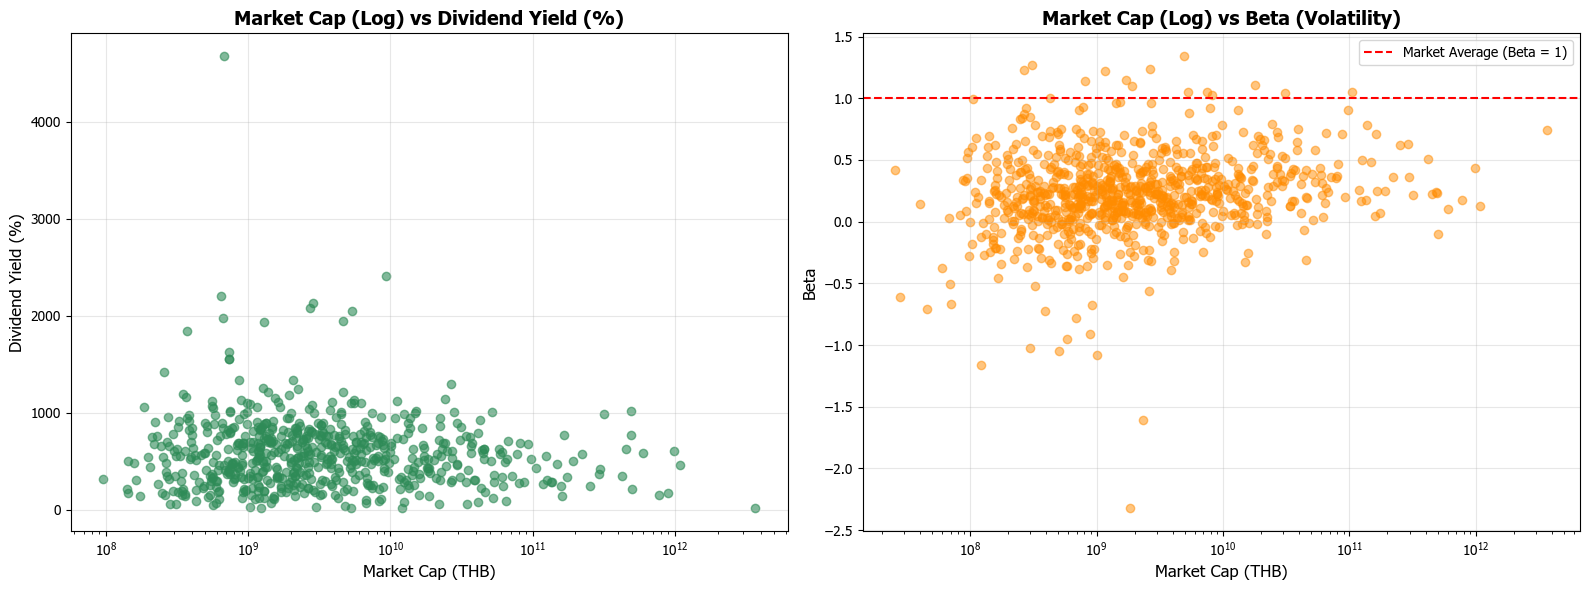

In [2]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display, Markdown

warnings.filterwarnings('ignore') 
plt.rcParams['font.family'] = 'Tahoma' 

# ==========================================
# 0. Connect & Fetch from New Tables
# ==========================================
conn = psycopg2.connect(host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459")

# ใช้ตารางใหม่ _v2 ทั้งหมด
query = """
    SELECT 
        s.symbol, 
        s.company_name_th AS company_name, 
        s.industry_group, 
        s.sector_th AS sector,
        y.market_cap, 
        y.current_price, 
        y.beta, 
        y.dividend_yield
    FROM set_master_v2 s
    LEFT JOIN yfinance_info_v2 y ON s.symbol = y.symbol
"""
df_clean = pd.read_sql(query, conn)

# Clean ข้อมูลสำหรับคำนวณ
df_clean = df_clean.dropna(subset=['market_cap', 'current_price']).copy()
df_clean = df_clean[df_clean['market_cap'] > 0]
df_clean['industry_group'] = df_clean['industry_group'].replace('-', 'N/A').fillna('N/A')
df_clean['sector'] = df_clean['sector'].replace('-', 'N/A').fillna('N/A')

# ==========================================
# 5.1 & 5.2: Total Stocks and Names
# ==========================================
display(Markdown("### 📌 5.1 & 5.2 Overview: Total Stocks and Names"))
df_overview = pd.DataFrame({
    "Question": ["5.1 How many stocks?", "5.2 List all stock name? (Preview)"],
    "Answer": [len(df_clean), ", ".join(df_clean['symbol'].tolist()[:15]) + " ..."]
})
display(df_overview)

# ==========================================
# 5.3 & 5.4: Stock Categories
# ==========================================
display(Markdown("### 📌 5.3 & 5.4 Overview: Stock Categories"))
df_cat_count = pd.DataFrame({
    "Hierarchy Level": ["Level 1: Industry Group (กลุ่มอุตสาหกรรม)", "Level 2: Sector (หมวดธุรกิจ)"],
    "Total Categories": [df_clean['industry_group'].nunique(), df_clean['sector'].nunique()],
    "List of Categories (Preview)": [
        ", ".join(df_clean['industry_group'].unique().tolist()[:5]) + " ...",
        ", ".join(df_clean['sector'].unique().tolist()[:5]) + " ..."
    ]
})
display(df_cat_count)

# ==========================================
# 5.5: List stock in each categories
# ==========================================
display(Markdown("### 📌 5.5 List of Stocks in Each Category (By Industry Group & Sector)"))

# Group by Industry
df_ind_grouped = df_clean.groupby('industry_group')['symbol'].apply(list).reset_index()
df_ind_grouped['Total Stocks'] = df_ind_grouped['symbol'].apply(len)
df_ind_grouped['Stock List'] = df_ind_grouped['symbol'].apply(lambda x: ", ".join(x[:10]) + ("..." if len(x)>10 else ""))
df_ind_grouped = df_ind_grouped[['industry_group', 'Total Stocks', 'Stock List']].sort_values(by='Total Stocks', ascending=False).reset_index(drop=True)
display(Markdown("**Level 1: By Industry Group**"))
display(df_ind_grouped) 

# Group by Sector
df_sec_grouped = df_clean.groupby('sector')['symbol'].apply(list).reset_index()
df_sec_grouped['Total Stocks'] = df_sec_grouped['symbol'].apply(len)
df_sec_grouped['Stock List'] = df_sec_grouped['symbol'].apply(lambda x: ", ".join(x[:8]) + ("..." if len(x)>8 else ""))
df_sec_grouped = df_sec_grouped[['sector', 'Total Stocks', 'Stock List']].sort_values(by='Total Stocks', ascending=False).reset_index(drop=True)
display(Markdown("**Level 2: By Sector (Top 10)**"))
display(df_sec_grouped.head(10))

# ==========================================
# 5.6 - 5.9: Market Cap Analysis
# ==========================================
display(Markdown("### 📌 5.6 - 5.9 Market Cap Analysis"))
large_stock = df_clean.loc[df_clean['market_cap'].idxmax()]
small_stock = df_clean.loc[df_clean['market_cap'].idxmin()]

df_minmax_cap = pd.DataFrame({
    "Question": ["5.6 Largest Market Cap", "5.7 Smallest Market Cap"],
    "Symbol": [large_stock['symbol'], small_stock['symbol']],
    "Market Cap (THB)": [f"{large_stock['market_cap']:,.2f}", f"{small_stock['market_cap']:,.2f}"]
})
display(df_minmax_cap)

display(Markdown("**5.8 Sort Ascending (Top 5 Smallest)**"))
df_asc = df_clean.sort_values(by='market_cap', ascending=True)[['symbol', 'company_name', 'market_cap']].head()
display(df_asc.style.format({"market_cap": "{:,.2f}"}))

display(Markdown("**5.9 Sort Descending (Top 5 Largest)**"))
df_desc = df_clean.sort_values(by='market_cap', ascending=False)[['symbol', 'company_name', 'market_cap']].head()
display(df_desc.style.format({"market_cap": "{:,.2f}"}))

# ==========================================
# 5.11 & 5.12: Min and Max Price
# ==========================================
display(Markdown("### 📌 5.11 & 5.12 Minimum and Maximum Price"))
min_price = df_clean.loc[df_clean['current_price'].idxmin()]
max_price = df_clean.loc[df_clean['current_price'].idxmax()]

df_minmax_price = pd.DataFrame({
    "Question": ["5.11 Minimum Price Stock", "5.12 Maximum Price Stock"],
    "Symbol": [min_price['symbol'], max_price['symbol']],
    "Price (THB)": [f"{min_price['current_price']:,.2f}", f"{max_price['current_price']:,.2f}"]
})
display(df_minmax_price)

# ==========================================
# 5.10: Plot Correlation Based on Market Cap
# ==========================================
display(Markdown("### 📌 5.10 Plot Correlation Based on Market Cap"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# กราฟ 1: Market Cap vs Dividend Yield
df_div = df_clean[df_clean['dividend_yield'] > 0].copy()
axes[0].scatter(df_div['market_cap'], df_div['dividend_yield'] * 100, alpha=0.6, color='seagreen')
axes[0].set_xscale('log')
axes[0].set_title('Market Cap (Log) vs Dividend Yield (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Market Cap (THB)', fontsize=12)
axes[0].set_ylabel('Dividend Yield (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# กราฟ 2: Market Cap vs Beta
df_beta = df_clean.dropna(subset=['beta'])
axes[1].scatter(df_beta['market_cap'], df_beta['beta'], alpha=0.5, color='darkorange')
axes[1].axhline(1.0, color='red', linestyle='--', label='Market Average (Beta = 1)')
axes[1].set_xscale('log')
axes[1].set_title('Market Cap (Log) vs Beta (Volatility)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Market Cap (THB)', fontsize=12)
axes[1].set_ylabel('Beta', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 5.13 - 5.20 Calculate and Plot SET, SET100, SET50, and MAI Indices

**ผลการคำนวณดัชนีจำลอง (Base 1000) 5 วันล่าสุด:**

,SET Index,SET100 Index,SET50 Index,MAI Index
date,,,,
2026-04-02 00:00:00,981.25,1431.78,1644.12,686.27
2026-04-03 00:00:00,973.46,1420.14,1631.50,682.01
2026-04-07 00:00:00,980.53,1432.31,1646.03,676.21
2026-04-08 00:00:00,994.35,1452.86,1669.69,667.63
2026-04-09 00:00:00,985.95,1454.11,1677.96,587.27


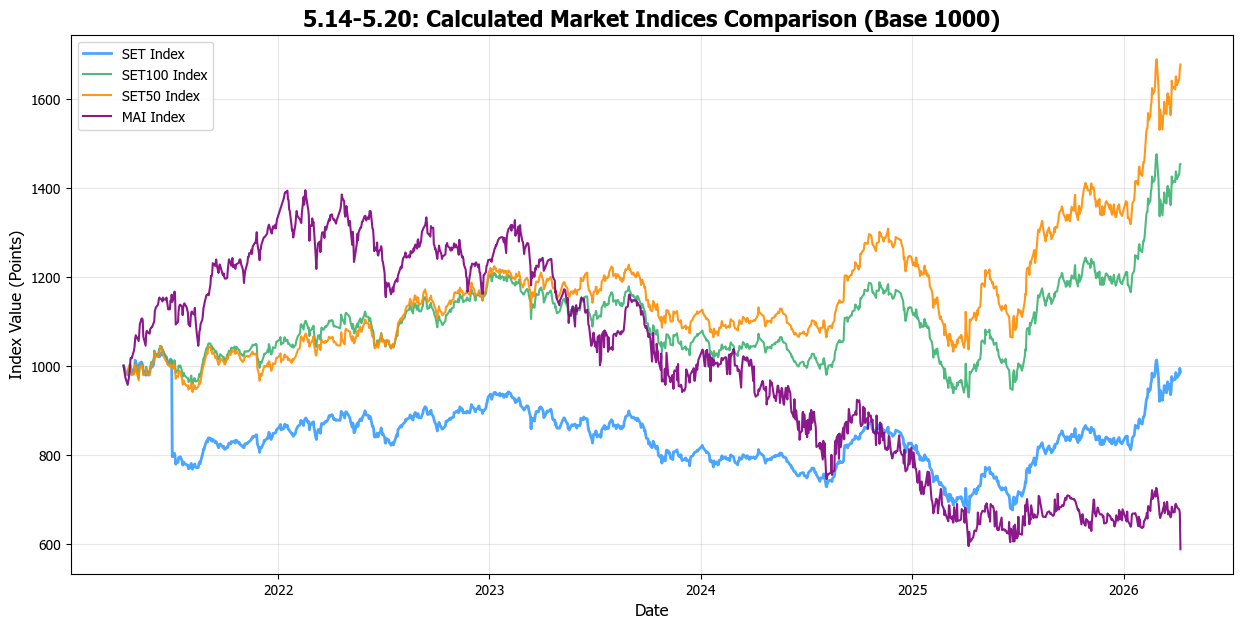

### 📌 5.21 & 5.22 Calculate and Plot Indexing of EACH Stock Categories

**ผลการคำนวณดัชนีกลุ่มอุตสาหกรรม (เรียงตามผลตอบแทนล่าสุด):**

industry_group,เทคโนโลยี,ธุรกิจการเงิน,ทรัพยากร,อสังหาริมทรัพย์และก่อสร้าง,บริการ,สินค้าอุตสาหกรรม,สินค้าอุปโภคบริโภค,เกษตรและอุตสาหกรรมอาหาร
date,,,,,,,,
2026-04-02 00:00:00,3997.29,1529.92,1124.86,835.76,828.02,642.91,582.93,164.06
2026-04-03 00:00:00,3995.91,1521.96,1100.16,832.03,821.62,636.07,579.92,162.14
2026-04-07 00:00:00,4048.53,1523.97,1114.15,834.38,819.37,653.66,575.30,162.28
2026-04-08 00:00:00,4129.18,1542.52,1114.54,851.15,842.21,639.86,577.56,161.97
2026-04-09 00:00:00,4226.09,1508.24,1107.66,833.75,817.57,608.06,519.34,154.43


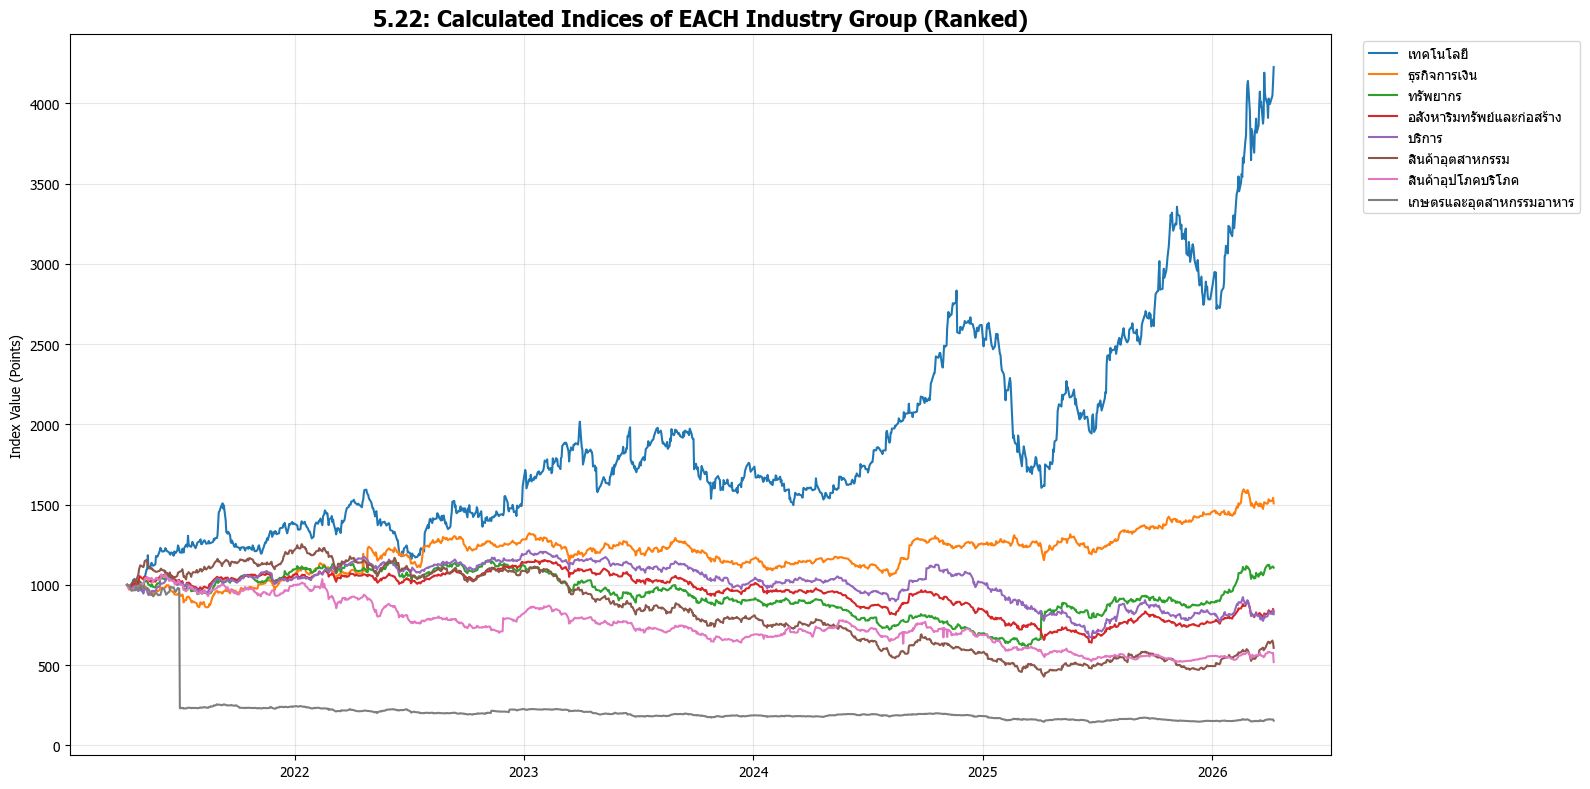

In [23]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from IPython.display import display, Markdown

warnings.filterwarnings('ignore') 
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.titlesize'] = 14

conn = psycopg2.connect(host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459")

# ==========================================
# 🛠️ ฟังก์ชันล้างบัคข้อมูลกระโดดจาก Yahoo Finance
# ==========================================
def clean_glitches(df, max_pct=0.10):
    df_clean = df.copy()
    if isinstance(df_clean, pd.Series):
        df_clean[df_clean.pct_change().abs() > max_pct] = np.nan
    else:
        for col in df_clean.columns:
            df_clean.loc[df_clean[col].pct_change().abs() > max_pct, col] = np.nan
    return df_clean.fillna(method='ffill')

# ==========================================
# 5.13 - 5.20: Calculate and Plot Market Indices
# ==========================================
display(Markdown("### 📌 5.13 - 5.20 Calculate and Plot SET, SET100, SET50, and MAI Indices"))

def calc_index(market, limit=None):
    limit_sql = f"ORDER BY y.market_cap DESC NULLS LAST LIMIT {limit}" if limit else ""
    query = f"""
    WITH index_stocks AS (
        SELECT s.symbol, (y.market_cap / NULLIF(y.current_price, 0)) AS shares_out
        FROM set_master_v2 s JOIN yfinance_info_v2 y ON s.symbol = y.symbol
        WHERE s.market = '{market}' AND y.market_cap > 0 {limit_sql}
    ),
    daily_cap AS (
        SELECT p.date, SUM(p.close * i.shares_out) AS total_market_cap
        FROM daily_prices_v2 p JOIN index_stocks i ON p.symbol = i.symbol GROUP BY p.date
    )
    SELECT date, (total_market_cap / FIRST_VALUE(total_market_cap) OVER (ORDER BY date)) * 1000 AS idx_val
    FROM daily_cap ORDER BY date;
    """
    df = pd.read_sql(query, conn)
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date')['idx_val']

# 🎯 5.13, 5.15, 5.17, 5.19 (Calculate)
df_indices = pd.concat([
    calc_index('SET'), calc_index('SET', 100), calc_index('SET', 50), calc_index('mai')
], axis=1)
df_indices.columns = ['SET Index', 'SET100 Index', 'SET50 Index', 'MAI Index']
df_indices = clean_glitches(df_indices, 0.15) # ล้างบัคดัชนี

display(Markdown("**ผลการคำนวณดัชนีจำลอง (Base 1000) 5 วันล่าสุด:**"))
display(df_indices.tail().style.format("{:.2f}"))

# 🎯 5.14, 5.16, 5.18, 5.20 (Plot)
plt.figure(figsize=(15, 7))
colors = ['dodgerblue', 'mediumseagreen', 'darkorange', 'purple']
for col, color in zip(df_indices.columns, colors):
    lw = 2 if col == 'SET Index' else 1.5
    alpha = 0.8 if col == 'SET Index' else 0.9
    plt.plot(df_indices.index, df_indices[col], color=color, label=col, linewidth=lw, alpha=alpha)

plt.title('5.14-5.20: Calculated Market Indices Comparison (Base 1000)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Index Value (Points)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 5.21 & 5.22: Indexing of EACH Stock Categories
# ==========================================
display(Markdown("### 📌 5.21 & 5.22 Calculate and Plot Indexing of EACH Stock Categories"))

# 🎯 5.21 Calculate
query_sec = """
WITH sec_stocks AS (
    SELECT s.symbol, s.industry_group, (y.market_cap / NULLIF(y.current_price, 0)) AS shares_out
    FROM set_master_v2 s JOIN yfinance_info_v2 y ON s.symbol = y.symbol
    WHERE s.industry_group != 'N/A' AND y.market_cap > 0
),
daily_sec_cap AS (
    SELECT p.date, ss.industry_group, SUM(p.close * ss.shares_out) AS total_cap
    FROM daily_prices_v2 p JOIN sec_stocks ss ON p.symbol = ss.symbol GROUP BY p.date, ss.industry_group
)
SELECT date, industry_group, (total_cap / FIRST_VALUE(total_cap) OVER (PARTITION BY industry_group ORDER BY date)) * 1000 AS idx_val
FROM daily_sec_cap ORDER BY date, industry_group;
"""
df_sec = pd.read_sql(query_sec, conn)
df_sec['date'] = pd.to_datetime(df_sec['date'])
df_pivot_sec = df_sec.pivot(index='date', columns='industry_group', values='idx_val')
df_pivot_sec = clean_glitches(df_pivot_sec, 0.15) # ล้างบัคกลุ่มอุตสาหกรรม

# จัดเรียงจากเก่งสุดไปอ่อนสุด
latest = df_pivot_sec.ffill().iloc[-1].sort_values(ascending=False)
df_pivot_sec = df_pivot_sec[latest.index]

display(Markdown("**ผลการคำนวณดัชนีกลุ่มอุตสาหกรรม (เรียงตามผลตอบแทนล่าสุด):**"))
display(df_pivot_sec.tail().style.format("{:.2f}"))

# 🎯 5.22 Plot
plt.figure(figsize=(16, 8))
for col in df_pivot_sec.columns:
    plt.plot(df_pivot_sec.index, df_pivot_sec[col], label=col, linewidth=1.5)
plt.title('5.22: Calculated Indices of EACH Industry Group (Ranked)', fontsize=16, fontweight='bold')
plt.ylabel('Index Value (Points)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 📌 5.23 & 5.24 Correlation between Stocks and SET Index

**✅ 5.24 Which stocks move close to SET index most?**

👉 หุ้นที่เคลื่อนไหวสอดคล้องกับ SET Index มากที่สุดคือ **GULF** (Correlation = 0.7698)

,Stock Symbol,Correlation with SET
0,GULF,0.769834
1,TIDLOR,0.598389
2,TURBO,0.563812
3,CPAXT,0.547117
4,CPN,0.483267
5,SGC,0.482275
6,ATLAS,0.476977
7,AWC,0.469501
8,CPALL,0.466306
9,CRC,0.465291


#### 📊 5.23 Plot Correlation between Stocks with SET

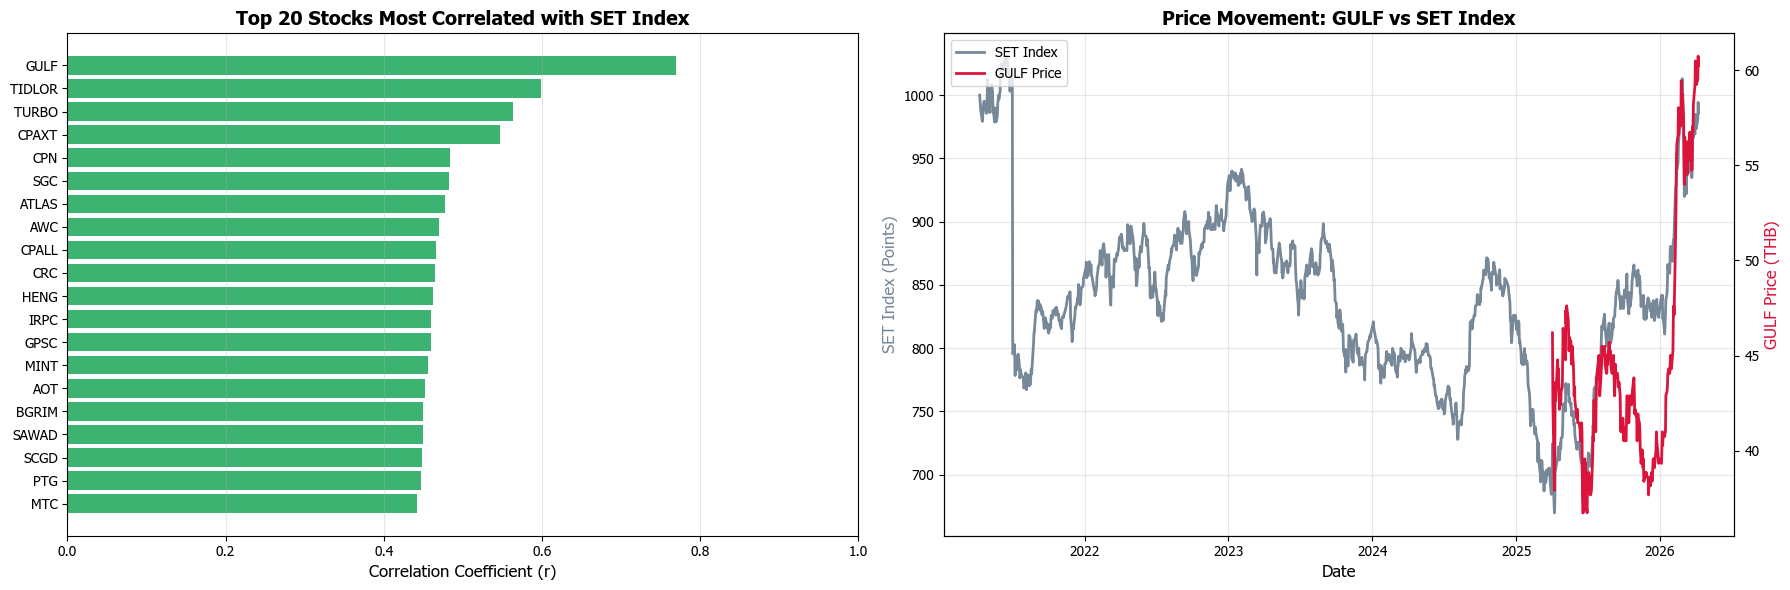

### 📌 5.25 & 5.26 Stock-to-Stock Correlation

**✅ 5.26 Which stocks is close to stocks most?**

👉 คู่หุ้นที่เป็นฝาแฝดกันคือ **MICRO** และ **RT** (Correlation = 0.9912)

#### 📊 5.25 Plot correlation between stocks and stocks (Heatmap)

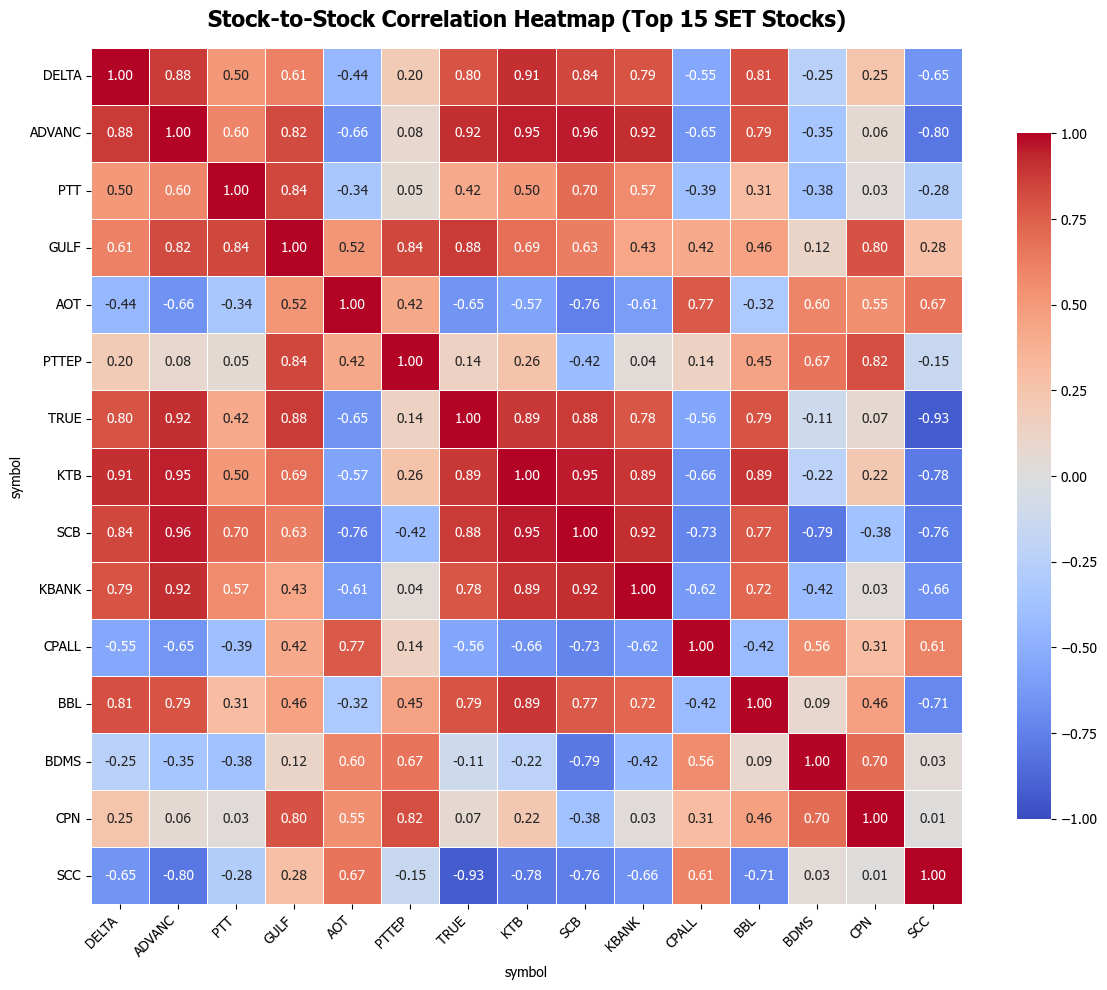

#### 📊 บทพิสูจน์หุ้นแฝด: MICRO vs RT

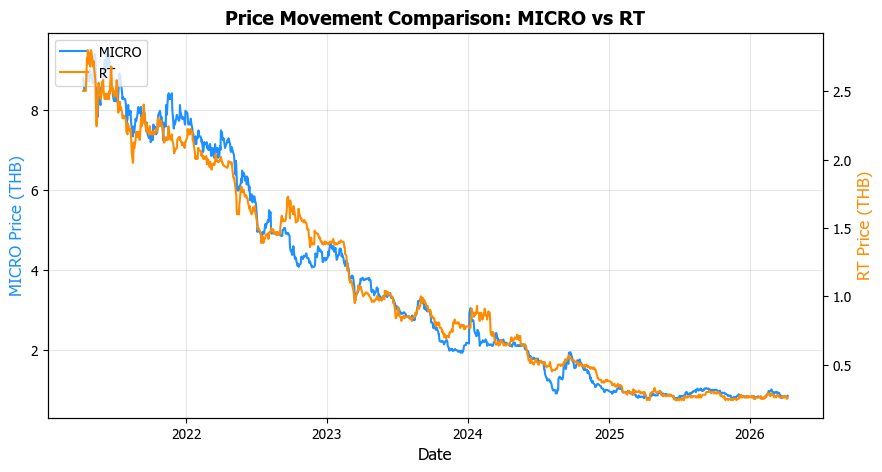

In [25]:
def clean_yf_glitches(df, max_pct_change=0.10):
    """ตัดข้อมูลวันที่ราคา/ดัชนีกระโดดรุนแรงผิดปกติ (เช่น วันล่าสุดที่ YF ชอบบัค)"""
    df_clean = df.copy()
    if isinstance(df_clean, pd.Series):
        pct_change = df_clean.pct_change().abs()
        df_clean[pct_change > max_pct_change] = np.nan
    else:
        for col in df_clean.columns:
            pct_change = df_clean[col].pct_change().abs()
            df_clean.loc[pct_change > max_pct_change, col] = np.nan
    return df_clean.fillna(method='ffill')

# ==========================================
# เตรียมข้อมูลราคาดัชนี และ หุ้นทุกตัว
# ==========================================
# ⭐️ แก้ไข Error ตรงนี้: เปลี่ยน c.market_cap เป็น y.market_cap
query_set = """
    WITH index_stocks AS (
        SELECT c.symbol, (y.market_cap / NULLIF(y.current_price, 0)) AS shares_out
        FROM set_master_v2 c JOIN yfinance_info_v2 y ON c.symbol = y.symbol
        WHERE c.market = 'SET' AND y.market_cap > 0
    ),
    daily_cap AS (
        SELECT p.date, SUM(p.close * i.shares_out) AS total_market_cap
        FROM daily_prices_v2 p JOIN index_stocks i ON p.symbol = i.symbol
        GROUP BY p.date
    )
    SELECT date, (total_market_cap / FIRST_VALUE(total_market_cap) OVER (ORDER BY date)) * 1000 AS set_index
    FROM daily_cap ORDER BY date;
"""
df_set_corr = pd.read_sql(query_set, conn)
df_set_corr['date'] = pd.to_datetime(df_set_corr['date'])
df_set_corr.set_index('date', inplace=True)
# คลีนบัคดัชนีกระโดด
df_set_corr['set_index'] = clean_yf_glitches(df_set_corr['set_index'], max_pct_change=0.10)

# ดึงราคาหุ้นทุกตัว
query_prices = "SELECT p.date, p.symbol, p.close FROM daily_prices_v2 p JOIN set_master_v2 s ON p.symbol = s.symbol WHERE s.market = 'SET'"
df_prices = pd.read_sql(query_prices, conn)
df_prices['date'] = pd.to_datetime(df_prices['date'])
df_pivot_stocks = df_prices.pivot(index='date', columns='symbol', values='close').fillna(method='ffill')
# คลีนบัคราคาหุ้นรายตัวกระโดด (ตั้งไว้ที่ 30% เผื่อหุ้นซิ่งของจริง)
df_pivot_stocks = clean_yf_glitches(df_pivot_stocks, max_pct_change=0.30)


# ==========================================
# 5.23 & 5.24: Correlation between Stocks and SET Index
# ==========================================
display(Markdown("### 📌 5.23 & 5.24 Correlation between Stocks and SET Index"))

# หา Correlation ด้วย Daily Returns (ชัวร์สุด)
returns = df_pivot_stocks.pct_change()
set_returns = df_set_corr['set_index'].pct_change()

# หาหุ้นที่ตรงกับ SET มากที่สุด
stock_correlations = returns.corrwith(set_returns).dropna().sort_values(ascending=False)
top_stock = stock_correlations.index[0]
top_corr_value = stock_correlations.iloc[0]

display(Markdown(f"**✅ 5.24 Which stocks move close to SET index most?**"))
display(Markdown(f"👉 หุ้นที่เคลื่อนไหวสอดคล้องกับ SET Index มากที่สุดคือ **{top_stock}** (Correlation = {top_corr_value:.4f})"))

# โชว์ Top 10
df_top10_corr = stock_correlations.head(10).reset_index()
df_top10_corr.columns = ['Stock Symbol', 'Correlation with SET']
display(df_top10_corr)

display(Markdown("#### 📊 5.23 Plot Correlation between Stocks with SET"))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# กราฟแท่งแนวนอน (Top 20)
top_20 = stock_correlations.head(20)
axes[0].barh(top_20.index[::-1], top_20.values[::-1], color='mediumseagreen')
axes[0].set_title('Top 20 Stocks Most Correlated with SET Index', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient (r)', fontsize=12)
axes[0].set_xlim(0, 1)
axes[0].grid(axis='x', alpha=0.3)

# ⭐️ กราฟ 2 แกน (Twin Axes) - ปรับปรุงแก้บัคแล้ว!
ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(df_set_corr.index, df_set_corr['set_index'], color='lightslategray', linewidth=2, label='SET Index')
ax2.plot(df_pivot_stocks.index, df_pivot_stocks[top_stock], color='crimson', linewidth=2, label=f'{top_stock} Price')

ax1.set_title(f'Price Movement: {top_stock} vs SET Index', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('SET Index (Points)', color='lightslategray', fontsize=12)
ax2.set_ylabel(f'{top_stock} Price (THB)', color='crimson', fontsize=12)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 5.25 & 5.26: Stock-to-Stock Correlation
# ==========================================
display(Markdown("### 📌 5.25 & 5.26 Stock-to-Stock Correlation"))

corr_matrix_all = df_pivot_stocks.corr()
mask_all = np.tril(np.ones(corr_matrix_all.shape), k=0).astype(bool)
upper_tri_all = corr_matrix_all.where(~mask_all)

max_corr_value = upper_tri_all.max().max()
stock_a, stock_b = upper_tri_all.stack().idxmax()

display(Markdown(f"**✅ 5.26 Which stocks is close to stocks most?**"))
display(Markdown(f"👉 คู่หุ้นที่เป็นฝาแฝดกันคือ **{stock_a}** และ **{stock_b}** (Correlation = {max_corr_value:.4f})"))

display(Markdown("#### 📊 5.25 Plot correlation between stocks and stocks (Heatmap)"))

query_top15 = "SELECT symbol FROM yfinance_info_v2 WHERE market_cap > 0 ORDER BY market_cap DESC LIMIT 15"
top15_symbols = pd.read_sql(query_top15, conn)['symbol'].tolist()
corr_top15 = df_pivot_stocks[top15_symbols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top15, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.title('Stock-to-Stock Correlation Heatmap (Top 15 SET Stocks)', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# กราฟพิสูจน์แฝด (Twin Axes)
display(Markdown(f"#### 📊 บทพิสูจน์หุ้นแฝด: {stock_a} vs {stock_b}"))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(df_pivot_stocks.index, df_pivot_stocks[stock_a], color='dodgerblue', linewidth=1.5, label=f'{stock_a}')
ax2.plot(df_pivot_stocks.index, df_pivot_stocks[stock_b], color='darkorange', linewidth=1.5, label=f'{stock_b}')

ax1.set_title(f'Price Movement Comparison: {stock_a} vs {stock_b}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel(f'{stock_a} Price (THB)', color='dodgerblue', fontsize=12)
ax2.set_ylabel(f'{stock_b} Price (THB)', color='darkorange', fontsize=12)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.show()

In [28]:
import pandas as pd
import psycopg2
from IPython.display import display, Markdown
import warnings

warnings.filterwarnings('ignore')

try:
    # 1. เชื่อมต่อ Database (ใช้ V2)
    conn = psycopg2.connect(host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459")
    
    # ==========================================
    # 💰 Part 1: Total Dividend (ข้อ 5.27 - 5.28)
    # ==========================================
    # (เปลี่ยนข้อ 5.29-5.30 ในโค้ดเก่าของคุณ ให้ตรงกับเลขโจทย์ 5.27-5.28)
    
    query_total = """
        SELECT 
            symbol, 
            SUM(dividend_amount) as total_dividend
        FROM fact_dividends
        WHERE ex_date >= CURRENT_DATE - INTERVAL '5 years'
        GROUP BY symbol
        ORDER BY total_dividend DESC;
    """
    df_total = pd.read_sql(query_total, conn)
    
    # 🎯 5.27 Which stocks is given dividend last 5 years?
    ans_5_27 = len(df_total)
    display(Markdown(f"### 📌 5.27 Which stocks is given dividend last 5 years?"))
    display(Markdown(f"👉 พบหุ้นที่จ่ายเงินปันผลในช่วง 5 ปีที่ผ่านมา จำนวนทั้งสิ้น **{ans_5_27}** บริษัท"))
    
    # 🎯 5.28 List stock is given dividend last 5 years from max to min
    display(Markdown(f"### 📌 5.28 List stock is given dividend last 5 years from max to min (Top 20)"))
    
    df_528 = df_total.head(20).copy()
    df_528['total_dividend'] = df_528['total_dividend'].apply(lambda x: f"{x:,.4f} ฿")
    df_528.columns = ['Symbol', 'Total Dividend (5 Years)']
    display(df_528)

    display(Markdown("---"))

    # ==========================================
    # 📈 Part 2: Growth Dividend (ข้อ 5.29 - 5.30)
    # ==========================================
    query_yearly = """
        SELECT 
            symbol, 
            EXTRACT(YEAR FROM ex_date) as pay_year, 
            SUM(dividend_amount) as yearly_div
        FROM fact_dividends
        WHERE ex_date >= CURRENT_DATE - INTERVAL '5 years'
        GROUP BY symbol, EXTRACT(YEAR FROM ex_date)
    """
    df_yearly = pd.read_sql(query_yearly, conn)
    df_pivot = df_yearly.pivot(index='symbol', columns='pay_year', values='yearly_div').fillna(0)
    
    years = sorted(df_pivot.columns.tolist())
    start_y, end_y = years[0], years[-1]
    
    # คำนวณคะแนน (Growth Score) และ Overall Growth %
    df_pivot['growth_score'] = 0
    for i in range(len(years) - 1):
        df_pivot['growth_score'] += (df_pivot[years[i+1]] > df_pivot[years[i]]).astype(int)
        
    df_pivot['overall_pct'] = df_pivot.apply(
        lambda row: ((row[end_y] - row[start_y]) / row[start_y] * 100) if row[start_y] > 0 else 0, 
        axis=1
    )
    
    # กรองและจัดเรียง (เอาหุ้นที่มี Growth Score เป็นบวก และ Overall เติบโต)
    df_filtered = df_pivot[(df_pivot['growth_score'] > 0) & (df_pivot['overall_pct'] > 0)].copy()
    df_filtered = df_filtered.sort_values(['growth_score', 'overall_pct'], ascending=[False, False]).head(20)
    df_filtered = df_filtered.reset_index()

    # 🎯 5.29 Which stocks is given growth dividend last 5 years?
    total_growth_stocks = len(df_pivot[(df_pivot['growth_score'] > 0) & (df_pivot['overall_pct'] > 0)])
    
    display(Markdown(f"### 📌 5.29 Which stocks is given growth dividend last 5 years?"))
    display(Markdown(f"👉 พบหุ้นที่มีการเติบโตของเงินปันผล (Growth Dividend) จำนวนทั้งสิ้น **{total_growth_stocks}** บริษัท"))

    # 🎯 5.30 List stock is given growth dividend last 5 years from max to min
    display(Markdown(f"### 📌 5.30 List stock is given growth dividend last 5 years from max to min (Top 20)"))
    
    # --- ตาราง 1: Yearly Dividend Amount (DPS) ---
    df_amount = pd.DataFrame()
    df_amount['Symbol'] = df_filtered['symbol']
    df_amount['Growth Score'] = df_filtered['growth_score'].apply(lambda x: f"{x}/{len(years)-1}")
    
    for y in years:
        df_amount[f"{int(y)} (Baht)"] = df_filtered[y].apply(lambda x: f"{x:.4f}" if x > 0 else "-")

    display(Markdown("**Table 1: Yearly Dividend Amount (Baht/Share)**"))
    display(df_amount)

    # --- ตาราง 2: Year-over-Year (YoY %) ---
    df_percent = pd.DataFrame()
    df_percent['Symbol'] = df_filtered['symbol']
    df_percent['Overall Growth'] = df_filtered['overall_pct'].apply(lambda x: f"{x:+.2f}%")
    
    for i in range(1, len(years)):
        prev_y = years[i-1]
        curr_y = years[i]
        col_name = f"{int(prev_y)} -> {int(curr_y)} (%)"
        
        def calc_yoy(row):
            old = row[prev_y]
            new = row[curr_y]
            if old == 0 and new > 0: return "N/A (New)"
            elif old == 0 and new == 0: return "-"
            else:
                pct = ((new - old) / old) * 100
                return f"{pct:+.2f}%"
                
        df_percent[col_name] = df_filtered.apply(calc_yoy, axis=1).values

    def color_growth(val):
        if isinstance(val, str):
            if val.startswith('-') and len(val) > 1:
                return 'color: #D32F2F; font-weight: bold;'
            elif val.startswith('+'):
                return 'color: #388E3C; font-weight: bold;'
        return ''

    cols_to_color = df_percent.columns[1:]
    
    try:
        styled_df = df_percent.style.map(color_growth, subset=cols_to_color)
    except AttributeError:
        styled_df = df_percent.style.applymap(color_growth, subset=cols_to_color)

    display(Markdown("**Table 2: Year-over-Year (YoY) Growth Percentage**"))
    display(styled_df)

except Exception as e:
    print(f"❌ Error: {e}")
finally:
    if 'conn' in locals() and conn:
        conn.close()

### 📌 5.27 Which stocks is given dividend last 5 years?

👉 พบหุ้นที่จ่ายเงินปันผลในช่วง 5 ปีที่ผ่านมา จำนวนทั้งสิ้น **766** บริษัท

### 📌 5.28 List stock is given dividend last 5 years from max to min (Top 20)

,Symbol,Total Dividend (5 Years)
0,KYE,85.5500 ฿
1,METCO,80.0000 ฿
2,STANLY,74.0000 ฿
3,ADVANC,68.9000 ฿
4,KWC,52.0000 ฿
5,ALUCON,50.0000 ฿
6,SCCC,47.0000 ฿
7,PTTEP,42.1250 ฿
8,SCC,40.0000 ฿
9,TISCO,38.7000 ฿


---

...

### 📌 5.30 List stock is given growth dividend last 5 years from max to min (Top 20)

**Table 1: Yearly Dividend Amount (Baht/Share)**

,Symbol,Growth Score,2021 (Baht),2022 (Baht),2023 (Baht),2024 (Baht),2025 (Baht),2026 (Baht)
0,ADVANC,5/5,3.4500,7.6900,8.2400,9.4800,12.6300,27.4100
1,TNL,4/5,0.0697,0.4980,0.2000,0.3000,0.4000,0.6000
2,BH,4/5,1.1500,3.2000,3.7000,5.1500,5.0000,9.0000
3,CCET,4/5,0.0169,0.0270,0.0491,0.1450,0.2000,0.0900
4,TTT,4/5,0.5000,1.0000,1.2500,2.1500,2.8000,1.5000
5,BIZ,4/5,0.1667,0.4278,0.2000,0.3000,0.3500,0.5000
6,BDMS,4/5,0.2500,0.5000,0.6500,0.7000,0.7500,0.6500
7,MC,4/5,0.2000,0.6000,0.8100,0.9000,0.9600,0.5200
8,LHSC,4/5,0.0996,0.3787,0.8372,1.0495,1.1450,0.2410
9,PT,4/5,0.2500,0.6100,0.6500,0.7000,1.2000,0.5000


**Table 2: Year-over-Year (YoY) Growth Percentage**

,Symbol,Overall Growth,2021 -> 2022 (%),2022 -> 2023 (%),2023 -> 2024 (%),2024 -> 2025 (%),2025 -> 2026 (%)
0,ADVANC,+694.49%,+122.90%,+7.15%,+15.05%,+33.23%,+117.02%
1,TNL,+760.83%,+614.49%,-59.84%,+50.00%,+33.33%,+50.00%
2,BH,+682.61%,+178.26%,+15.62%,+39.19%,-2.91%,+80.00%
3,CCET,+432.54%,+59.76%,+81.85%,+195.32%,+37.93%,-55.00%
4,TTT,+200.00%,+100.00%,+25.00%,+72.00%,+30.23%,-46.43%
5,BIZ,+199.94%,+156.63%,-53.25%,+50.00%,+16.67%,+42.86%
6,BDMS,+160.00%,+100.00%,+30.00%,+7.69%,+7.14%,-13.33%
7,MC,+160.00%,+200.00%,+35.00%,+11.11%,+6.67%,-45.83%
8,LHSC,+141.97%,+280.22%,+121.07%,+25.36%,+9.10%,-78.95%
9,PT,+100.00%,+144.00%,+6.56%,+7.69%,+71.43%,-58.33%


### 📌 5.31 & 5.32 Candlestick Charts

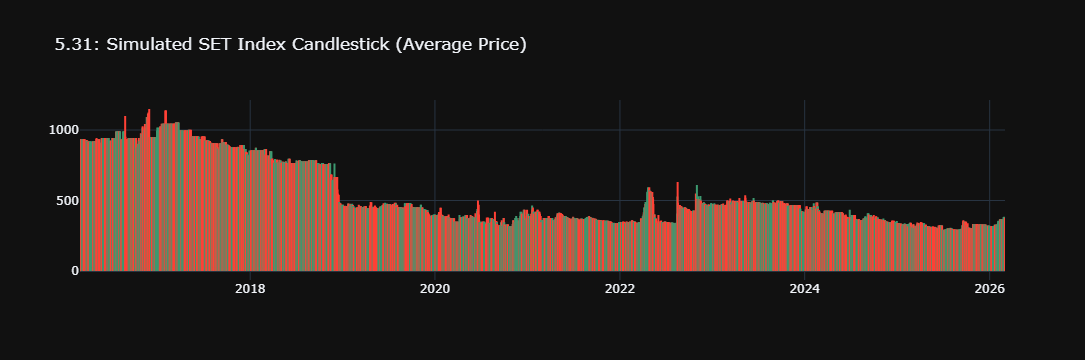

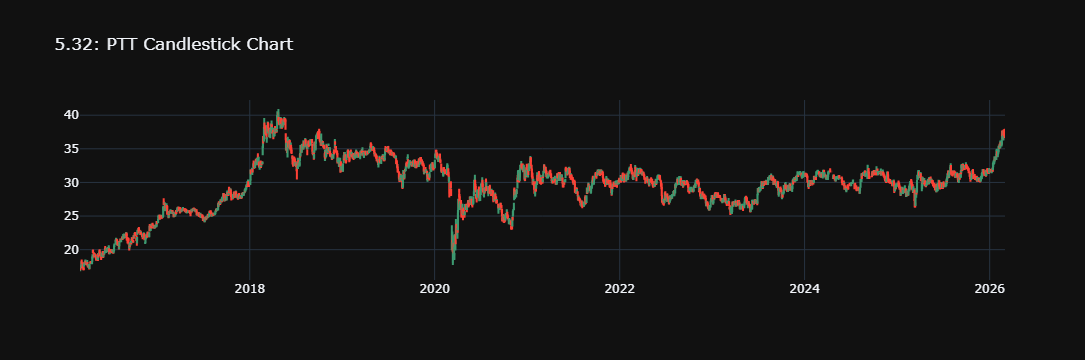

### 📌 5.33 - 5.36 Stock Classification

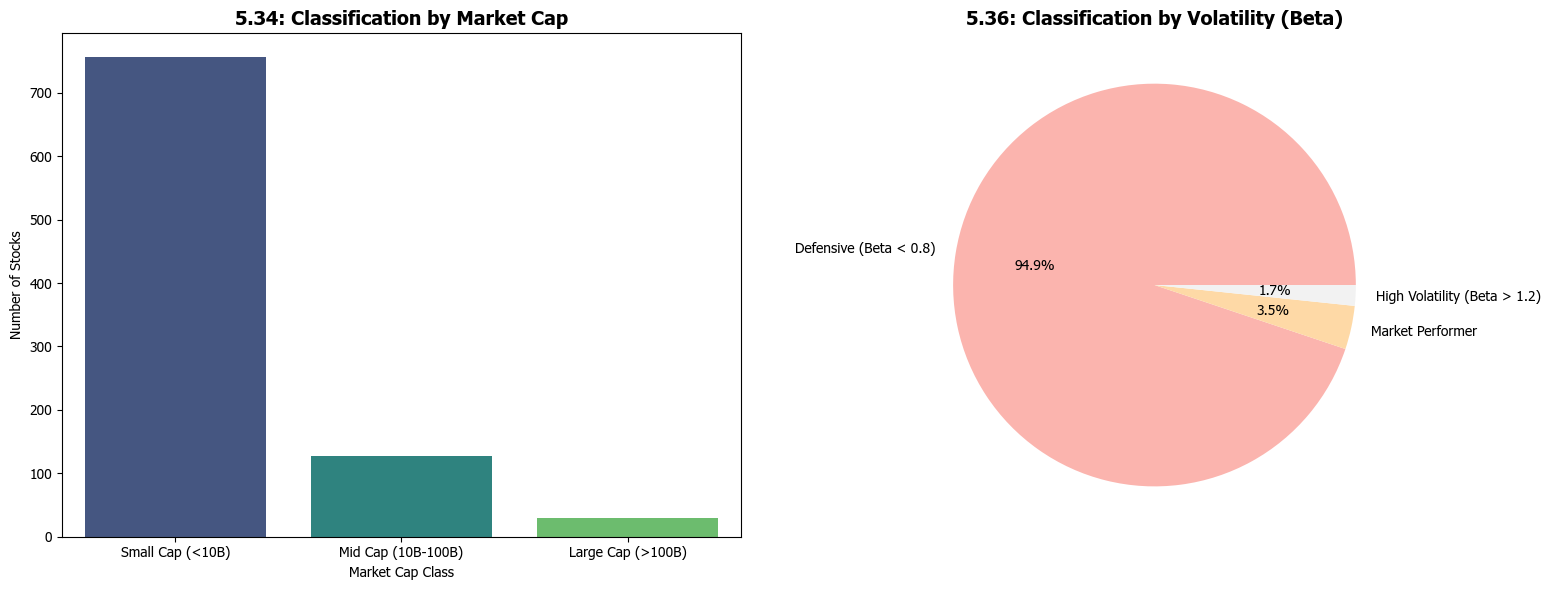

### 📌 5.39 & 5.40 High Volatility Stocks (Beta > 1)

*Which stocks move close to SET index that 1% of SET changed then that stock move far beyond than 1%?*

👉 พบหุ้นที่ผันผวนสูงกว่าตลาด (Beta > 1) จำนวน **16** ตัว

**Top 10 Most Volatile Stocks:**

,symbol,company_name_th,sector,beta
0,ETL,บริษัท ยูโรเอเชีย โทเทิล โลจิสติกส์ จำกัด (มหาชน),Industrials,1.820
1,GEL,บริษัท เจนเนอรัล เอนจิเนียริ่ง จำกัด (มหาชน),Basic Materials,1.477
2,WAVE,บริษัท เวฟ เอกซ์โพเนนเชียล จำกัด (มหาชน),Consumer Defensive,1.418
3,MCA,บริษัท มาร์เก็ต คอนเน็กชั่นส์ เอเชีย จำกัด (มหาชน),Communication Services,1.413
4,TEAM,บริษัท ทีมพรีซิชั่น จำกัด (มหาชน),Technology,1.270
5,XPG,บริษัท เอ็กซ์สปริง แคปปิตอล จำกัด (มหาชน),Financial Services,1.253
6,I2,บริษัท ไอ ทู เอ็นเตอร์ไพรซ์ จำกัด (มหาชน),Technology,1.237
7,SCGD,บริษัท เอสซีจี เดคคอร์ จำกัด (มหาชน),Basic Materials,1.223
8,BVG,บริษัท บลูเวนเจอร์ กรุ๊ป จำกัด (มหาชน),Technology,1.210
9,DEXON,บริษัท เด็กซ์ซอน เทคโนโลยี จำกัด (มหาชน),Energy,1.147


### 📌 5.41 & 5.42 Line Graphs

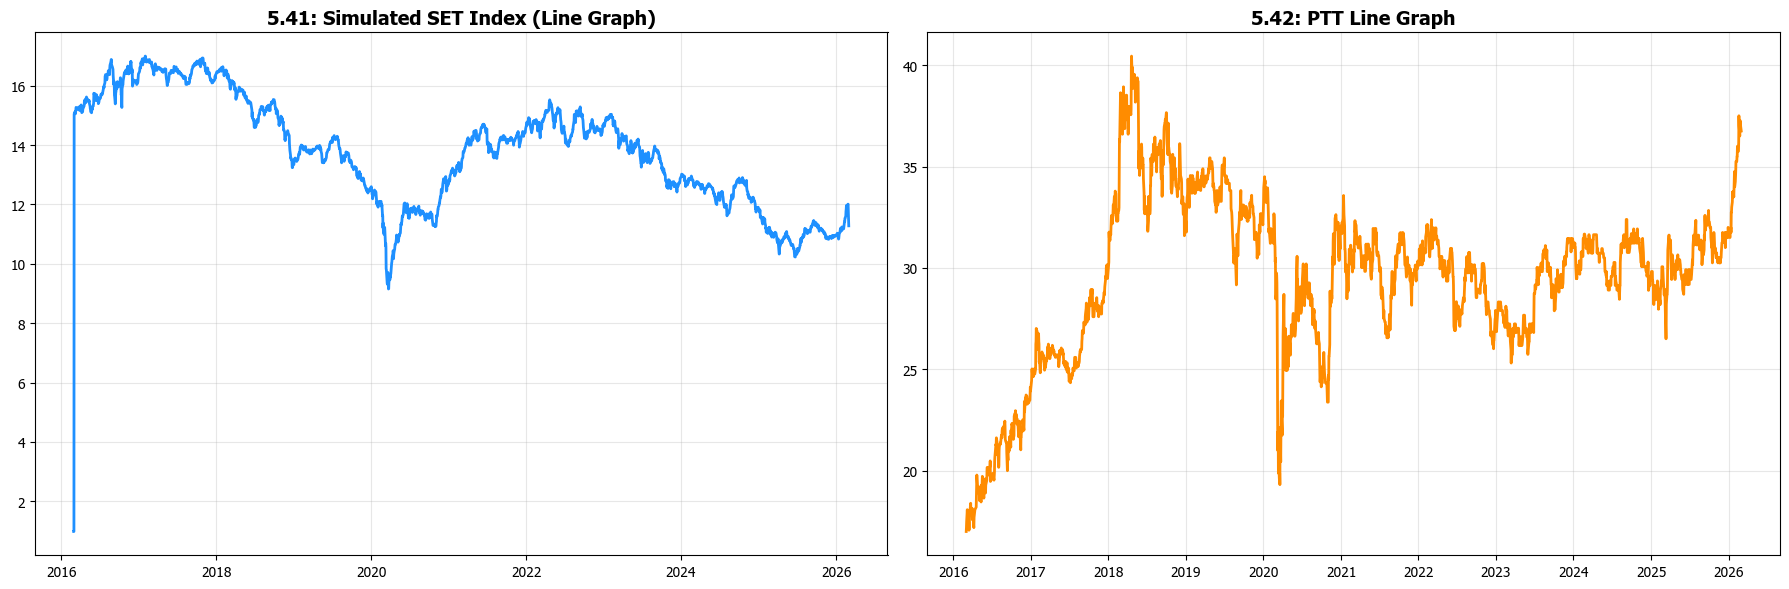

### 📌 5.43 & 5.44 Financial Ratios (ROE, D/E, P/E)

**Top 15 Stocks Ranked by Return on Equity (ROE):**

,symbol,company_name_th,sector,roe,pe_ratio,de_ratio
0,NTF,บริษัท เอ็นทีเอฟ อินเตอร์กรุ๊ป (ประเทศไทย) จำกัด (มหาชน),Consumer Defensive,85.62%,-,41.07
1,ITD,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),Industrials,84.39%,0.20,436.74
2,NETBAY,บริษัท เน็ตเบย์ จำกัด (มหาชน),Technology,58.33%,14.93,5.32
3,MRDIYT,บริษัท มิสเตอร์. ดี.ไอ.วาย. โฮลดิ้ง (ประเทศไทย) จำกัด (มหาชน),Consumer Cyclical,50.05%,25.14,160.55
4,ADVANC,บริษัท แอดวานซ์ อินโฟร์ เซอร์วิส จำกัด (มหาชน),Communication Services,46.81%,23.22,179.23
5,TACC,บริษัท ที.เอ.ซี. คอนซูเมอร์ จำกัด (มหาชน),Consumer Defensive,42.46%,11.63,5.27
6,PIS,บริษัท โปร อินไซด์ จำกัด (มหาชน),Technology,41.43%,22.25,122.08
7,COM7,บริษัท คอมเซเว่น จำกัด (มหาชน),Consumer Cyclical,41.26%,13.74,109.55
8,FSMART,บริษัท ฟอร์ท สมาร์ท เซอร์วิส จำกัด (มหาชน),Communication Services,40.95%,9.13,56.62
9,TFG,บริษัท ไทยฟู้ดส์ กรุ๊ป จำกัด (มหาชน),Consumer Defensive,40.70%,5.33,99.80


### 📌 5.37 & 5.38 Export Data and Schema

In [27]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings
import os
from IPython.display import display, Markdown

warnings.filterwarnings('ignore') 
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.titlesize'] = 14

conn = psycopg2.connect(host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459")

# ==========================================
# 5.31 & 5.32: Candlestick Charts
# ==========================================
display(Markdown("### 📌 5.31 & 5.32 Candlestick Charts"))

# 5.31: SET Index Candlestick (Simulated)
query_set_ohlc = """
    SELECT date, AVG(open) as open, MAX(high) as high, MIN(low) as low, AVG(close) as close
    FROM fact_daily_prices
    GROUP BY date
    ORDER BY date
"""
df_set_ohlc = pd.read_sql(query_set_ohlc, conn)

fig_set = go.Figure(data=[go.Candlestick(
    x=df_set_ohlc['date'], open=df_set_ohlc['open'], high=df_set_ohlc['high'],
    low=df_set_ohlc['low'], close=df_set_ohlc['close'], name='SET Proxy'
)])
fig_set.update_layout(title='5.31: Simulated SET Index Candlestick (Average Price)', template='plotly_dark', xaxis_rangeslider_visible=False)
fig_set.show()

# 5.32: Any Stock Candlestick (Example: PTT)
target_stock = 'PTT'
query_ptt = f"SELECT date, open, high, low, close FROM fact_daily_prices WHERE symbol='{target_stock}' ORDER BY date"
df_ptt = pd.read_sql(query_ptt, conn)

fig_ptt = go.Figure(data=[go.Candlestick(
    x=df_ptt['date'], open=df_ptt['open'], high=df_ptt['high'],
    low=df_ptt['low'], close=df_ptt['close'], name=target_stock
)])
fig_ptt.update_layout(title=f'5.32: {target_stock} Candlestick Chart', template='plotly_dark', xaxis_rangeslider_visible=False)
fig_ptt.show()


# ==========================================
# 5.33 - 5.36: Classification
# ==========================================
display(Markdown("### 📌 5.33 - 5.36 Stock Classification"))

query_class = "SELECT symbol, market_cap, beta FROM dim_companies_cleaned WHERE market_cap > 0"
df_class = pd.read_sql(query_class, conn)

# 5.33 & 5.34: By Market Cap
df_class['Market Cap Class'] = pd.cut(df_class['market_cap'], 
                                      bins=[0, 10e9, 100e9, float('inf')], 
                                      labels=['Small Cap (<10B)', 'Mid Cap (10B-100B)', 'Large Cap (>100B)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df_class, x='Market Cap Class', palette='viridis', ax=axes[0])
axes[0].set_title('5.34: Classification by Market Cap', fontweight='bold')
axes[0].set_ylabel('Number of Stocks')

# 5.35 & 5.36: By Beta (Volatility)
df_beta_class = df_class.dropna(subset=['beta']).copy()
df_beta_class['Risk Profile'] = pd.cut(df_beta_class['beta'], 
                                       bins=[0, 0.8, 1.2, float('inf')], 
                                       labels=['Defensive (Beta < 0.8)', 'Market Performer', 'High Volatility (Beta > 1.2)'])

df_beta_class['Risk Profile'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1', ax=axes[1])
axes[1].set_title('5.36: Classification by Volatility (Beta)', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


# ==========================================
# 5.39 & 5.40: High Volatility (Beta Analysis)
# ==========================================
display(Markdown("### 📌 5.39 & 5.40 High Volatility Stocks (Beta > 1)"))
display(Markdown("*Which stocks move close to SET index that 1% of SET changed then that stock move far beyond than 1%?*"))

query_high_beta = """
    SELECT symbol, company_name_th, sector, beta 
    FROM dim_companies_cleaned 
    WHERE beta > 1 
    ORDER BY beta DESC
"""
df_high_beta = pd.read_sql(query_high_beta, conn)

display(Markdown(f"👉 พบหุ้นที่ผันผวนสูงกว่าตลาด (Beta > 1) จำนวน **{len(df_high_beta)}** ตัว"))
display(Markdown("**Top 10 Most Volatile Stocks:**"))
display(df_high_beta.head(10).style.format({"beta": "{:.3f}"}))


# ==========================================
# 5.41 & 5.42: Line Graphs
# ==========================================
display(Markdown("### 📌 5.41 & 5.42 Line Graphs"))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 5.41: SET Index Line Graph
axes[0].plot(df_set_ohlc['date'], df_set_ohlc['close'], color='dodgerblue', linewidth=2)
axes[0].set_title('5.41: Simulated SET Index (Line Graph)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 5.42: Any Stock Line Graph (PTT)
axes[1].plot(df_ptt['date'], df_ptt['close'], color='darkorange', linewidth=2)
axes[1].set_title(f'5.42: {target_stock} Line Graph', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================
# 5.43 & 5.44: Financial Ratios (ROE, D/E, P/E)
# ==========================================
display(Markdown("### 📌 5.43 & 5.44 Financial Ratios (ROE, D/E, P/E)"))

query_ratios = """
    SELECT 
        c.symbol, 
        c.company_name_th, 
        c.sector,
        c.roe,
        y.trailing_pe as pe_ratio,
        f.debt_to_equity as de_ratio
    FROM dim_companies_cleaned c
    LEFT JOIN yfinance_stock_info y ON c.symbol = y.symbol
    LEFT JOIN fact_fundamentals_full f ON c.symbol = f.symbol
    WHERE c.roe IS NOT NULL OR y.trailing_pe IS NOT NULL
    ORDER BY c.roe DESC NULLS LAST
"""
df_ratios = pd.read_sql(query_ratios, conn)

display(Markdown("**Top 15 Stocks Ranked by Return on Equity (ROE):**"))
display(df_ratios.head(15).style.format({
    "roe": "{:.2f}%",
    "pe_ratio": "{:.2f}",
    "de_ratio": "{:.2f}"
}, na_rep="-"))


# ==========================================
# 5.37 & 5.38: Export Database
# ==========================================
display(Markdown("### 📌 5.37 & 5.38 Export Data and Schema"))

os.makedirs('exports_final', exist_ok=True)

# Export Data (CSV)
df_clean.to_csv('exports_final/companies_master.csv', index=False)
df_ratios.to_csv('exports_final/financial_ratios.csv', index=False)

# Export Schema
query_schema = "SELECT table_name, column_name, data_type FROM information_schema.columns WHERE table_schema='public'"
df_schema = pd.read_sql(query_schema, conn)
df_schema.to_csv('exports_final/database_schema.csv', index=False)

In [7]:
import os
import pandas as pd
from IPython.display import display, Markdown

display(Markdown("### 📌 5.37 & 5.38 Export Database Schema and Data (CSV & SQL)"))

# สร้างโฟลเดอร์ใหม่สำหรับเก็บไฟล์ของเวอร์ชัน V2 โดยเฉพาะ
export_dir = 'exports_v2'
os.makedirs(export_dir, exist_ok=True)

# ==========================================
# 1. Export Data to CSV (ข้อ 5.38)
# ==========================================
print("⏳ กำลัง Export ข้อมูลเป็นไฟล์ CSV...")

# บันทึกตารางหลักทั้ง 3 ตาราง
tables_to_export = ['set_master_v2', 'yfinance_info_v2', 'daily_prices_v2']
for table in tables_to_export:
    df_temp = pd.read_sql(f"SELECT * FROM {table}", conn)
    df_temp.to_csv(f"{export_dir}/{table}_data.csv", index=False)

# บันทึกตารางผลลัพธ์ทางการเงิน (ถ้ามีตัวแปร df_ratios จากเซลล์ก่อนหน้า)
if 'df_ratios' in locals():
    df_ratios.to_csv(f'{export_dir}/financial_ratios_calculated.csv', index=False)

print("✅ Export Data (CSV) สำเร็จ!")

# ==========================================
# 2. Export Schema to CSV (ข้อ 5.37)
# ==========================================
query_schema = f"""
    SELECT table_name, column_name, data_type 
    FROM information_schema.columns 
    WHERE table_schema='public' 
    AND table_name IN ('set_master_v2', 'yfinance_info_v2', 'daily_prices_v2')
"""
df_schema = pd.read_sql(query_schema, conn)
df_schema.to_csv(f'{export_dir}/database_schema.csv', index=False)
print("✅ Export Schema (CSV) สำเร็จ!")

# ==========================================
# 3. Export Schema to SQL (ข้อ 5.37)
# ==========================================
# เขียนคำสั่งโครงสร้างตาราง (CREATE TABLE) ออกมาเป็นไฟล์ .sql
schema_sql_content = """-- Database Schema for SET Quant V2
CREATE TABLE IF NOT EXISTS set_master_v2 (
    symbol VARCHAR(20) PRIMARY KEY, company_name_th VARCHAR(255), market VARCHAR(50),
    industry_group VARCHAR(100), sector_th VARCHAR(100), address TEXT, zipcode VARCHAR(20),
    phone VARCHAR(100), fax VARCHAR(100), website VARCHAR(255), updated_at TIMESTAMP
);

CREATE TABLE IF NOT EXISTS yfinance_info_v2 (
    symbol VARCHAR(20) PRIMARY KEY, long_name VARCHAR(255), sector VARCHAR(100), industry VARCHAR(100),
    market_cap BIGINT, beta FLOAT, dividend_yield FLOAT, trailing_pe FLOAT, current_price FLOAT, raw_info_json JSONB
);

CREATE TABLE IF NOT EXISTS daily_prices_v2 (
    symbol VARCHAR(20), date DATE, open FLOAT, high FLOAT, low FLOAT, close FLOAT, volume BIGINT,
    PRIMARY KEY (symbol, date)
);
"""
with open(f'{export_dir}/database_schema.sql', 'w', encoding='utf-8') as f:
    f.write(schema_sql_content)
print("✅ Export Schema (SQL) สำเร็จ!")

# ==========================================
# 4. Export Data to SQL (ข้อ 5.38)
# ==========================================
# เขียนคำสั่ง INSERT INTO ออกมาเป็นไฟล์ .sql (ทำเฉพาะตาราง set_master_v2 เพื่อเป็นตัวอย่าง เพราะตารางราคามีขนาดใหญ่มาก)
print("⏳ กำลัง Export ข้อมูลเป็นไฟล์ SQL (Data Dump)...")
df_sql_data = pd.read_sql("SELECT * FROM set_master_v2", conn)

with open(f'{export_dir}/set_master_v2_data.sql', 'w', encoding='utf-8') as f:
    f.write("-- Data Dump for set_master_v2\n")
    for _, row in df_sql_data.iterrows():
        vals = []
        for val in row:
            if pd.isna(val):
                vals.append("NULL")
            elif isinstance(val, str):
                # แทนที่ single quote ด้วย double single quote เพื่อไม่ให้ SQL Error
                vals.append(f"'{val.replace(chr(39), chr(39)+chr(39))}'")
            else:
                vals.append(str(val))
        f.write(f"INSERT INTO set_master_v2 VALUES ({', '.join(vals)}) ON CONFLICT DO NOTHING;\n")

print("✅ Export Data (SQL) สำเร็จ!")

display(Markdown(f"🎉 **เสร็จสิ้นโปรเจกต์! ไฟล์ทั้งหมดถูกจัดเก็บเรียบร้อยในโฟลเดอร์ `{export_dir}` ครับ**"))

# ปิดการเชื่อมต่อฐานข้อมูลอย่างเป็นทางการ
if 'conn' in locals() and conn:
    conn.close()
    print("🔒 Database connection closed.")

### 📌 5.37 & 5.38 Export Database Schema and Data (CSV & SQL)

⏳ กำลัง Export ข้อมูลเป็นไฟล์ CSV...
✅ Export Data (CSV) สำเร็จ!
✅ Export Schema (CSV) สำเร็จ!
✅ Export Schema (SQL) สำเร็จ!
⏳ กำลัง Export ข้อมูลเป็นไฟล์ SQL (Data Dump)...
✅ Export Data (SQL) สำเร็จ!


🎉 **เสร็จสิ้นโปรเจกต์! ไฟล์ทั้งหมดถูกจัดเก็บเรียบร้อยในโฟลเดอร์ `exports_v2` ครับ**

🔒 Database connection closed.
